In [84]:
!pip install plotly


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px



In [86]:
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\NetflixOriginals.csv",encoding = "ISO-8859-1")
df

,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi
...,...,...,...,...,...,...
579,Taylor Swift: Reputation Stadium Tour,Concert Film,"December 31, 2018",125,8.4,English
580,Winter on Fire: Ukraine's Fight for Freedom,Documentary,"October 9, 2015",91,8.4,English/Ukranian/Russian
581,Springsteen on Broadway,One-man show,"December 16, 2018",153,8.5,English
582,Emicida: AmarElo - It's All For Yesterday,Documentary,"December 8, 2020",89,8.6,Portuguese


In [87]:
df.shape

(584, 6)

In [88]:
df.describe()

,Runtime,IMDB Score
count,584.000000,584.000000
mean,93.577055,6.271747
std,27.761683,0.979256
min,4.000000,2.500000
25%,86.000000,5.700000
50%,97.000000,6.350000
75%,108.000000,7.000000
max,209.000000,9.000000


In [89]:
df.isnull().sum()

Title         0
Genre         0
Premiere      0
Runtime       0
IMDB Score    0
Language      0
dtype: int64

In [90]:
df["Premiere"] = pd.to_datetime(df["Premiere"], errors='coerce')

In [91]:
df["Year"] = df["Premiere"].dt.year.astype("Int64")
df["Month"] = df["Premiere"].dt.month_name()
df["Weekday"] = df["Premiere"].dt.day_name()
df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Month,Weekday
0,Enter the Anime,Documentary,2019-08-05,58,2.5,English/Japanese,2019,August,Monday
1,Dark Forces,Thriller,2020-08-21,81,2.6,Spanish,2020,August,Friday
2,The App,Science fiction/Drama,2019-12-26,79,2.6,Italian,2019,December,Thursday
3,The Open House,Horror thriller,2018-01-19,94,3.2,English,2018,January,Friday
4,Kaali Khuhi,Mystery,2020-10-30,90,3.4,Hindi,2020,October,Friday


# 1-In which language were the long-running films created according to the dataset? Make a visualization.

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Title       584 non-null    object        
 1   Genre       584 non-null    object        
 2   Premiere    579 non-null    datetime64[ns]
 3   Runtime     584 non-null    int64         
 4   IMDB Score  584 non-null    float64       
 5   Language    584 non-null    object        
 6   Year        579 non-null    Int64         
 7   Month       579 non-null    object        
 8   Weekday     579 non-null    object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 41.8+ KB


In [93]:
df["Language"].unique()

array(['English/Japanese', 'Spanish', 'Italian', 'English', 'Hindi',
       'Turkish', 'Korean', 'Indonesian', 'Malay', 'Dutch', 'French',
       'English/Spanish', 'Portuguese', 'Filipino', 'German', 'Polish',
       'Norwegian', 'Marathi', 'Thai', 'Swedish', 'Japanese',
       'Spanish/Basque', 'Spanish/Catalan', 'English/Swedish',
       'English/Taiwanese/Mandarin', 'Thia/English', 'English/Mandarin',
       'Georgian', 'Bengali', 'Khmer/English/French', 'English/Hindi',
       'Tamil', 'Spanish/English', 'English/Korean', 'English/Arabic',
       'English/Russian', 'English/Akan', 'English/Ukranian/Russian'],
      dtype=object)

In [94]:
df_temp = df.groupby("Language")["Runtime"].mean().sort_values(ascending=False)

In [95]:
df_temp

Language
English/Akan                  136.000000
Khmer/English/French          136.000000
Marathi                       121.666667
English/Korean                121.000000
Spanish/Catalan               116.000000
Korean                        115.833333
Hindi                         115.787879
English/Arabic                114.000000
Indonesian                    103.777778
Turkish                       101.800000
Malay                         101.000000
Thai                          101.000000
Tamil                         101.000000
Dutch                          99.666667
German                         99.600000
Filipino                       99.500000
Japanese                       99.333333
Polish                         98.666667
Italian                        98.357143
Spanish/English                96.000000
Spanish                        93.387097
French                         92.700000
English                        91.817955
Portuguese                     91.250000
English

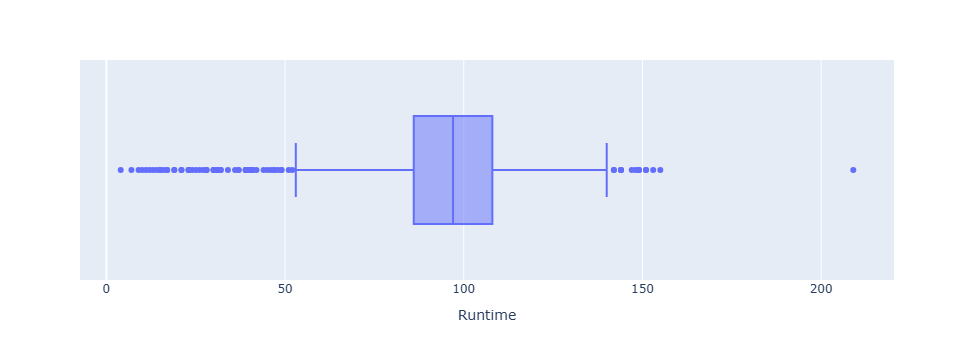

In [96]:
fig = px.box(df, x = 'Runtime',hover_data= df[['Title','Language']])
fig.show()

# 2-Find and visualize the IMDB values of the movies shot in the 'Documentary' genre between January 2019 and June 2020.

In [97]:
mask = (
    (df["Genre"] == "Documentary") &
    (df["Premiere"] >= "2019-01-01") &
    (df["Premiere"] <= "2020-06-30")
)

docum = df.loc[mask]
docum.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Month,Weekday
0,Enter the Anime,Documentary,2019-08-05,58,2.5,English/Japanese,2019,August,Monday
15,After the Raid,Documentary,2019-12-19,25,4.3,Spanish,2019,December,Thursday
20,"Hello Privilege. It's Me, Chelsea",Documentary,2019-09-13,64,4.4,English,2019,September,Friday
30,After Maria,Documentary,2019-05-24,37,4.6,English/Spanish,2019,May,Friday
151,One Take,Documentary,2020-06-18,85,5.7,Thai,2020,June,Thursday


In [98]:
docum[["Title","Premiere","IMDB Score"]]

,Title,Premiere,IMDB Score
0,Enter the Anime,2019-08-05,2.5
15,After the Raid,2019-12-19,4.3
20,"Hello Privilege. It's Me, Chelsea",2019-09-13,4.4
30,After Maria,2019-05-24,4.6
151,One Take,2020-06-18,5.7
263,A Tale of Two Kitchens,2019-05-22,6.3
286,The Legend of Cocaine Island,2019-03-29,6.3
290,Travis Scott: Look Mom I Can Fly,2019-08-28,6.3
295,Birders,2019-09-25,6.4
303,Murder to Mercy: The Cyntoia Brown Story,2020-04-29,6.4


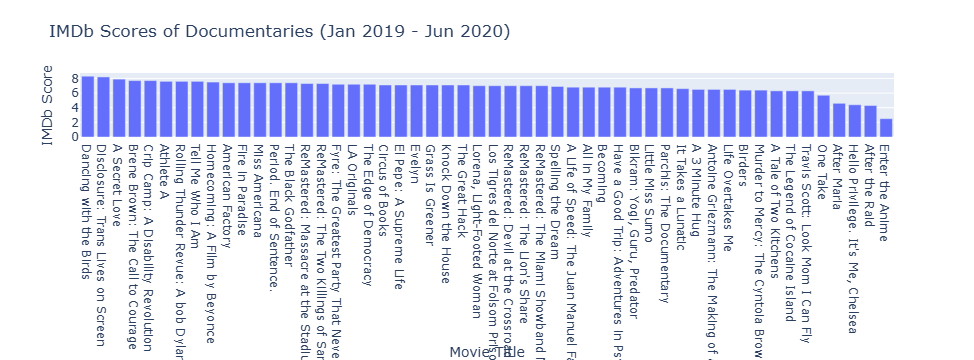

In [99]:
import plotly.express as px

fig = px.bar(
    docum,
    x="Title",
    y="IMDB Score",
    title="IMDb Scores of Documentaries (Jan 2019 - Jun 2020)",
    labels={"IMDB Score": "IMDb Score", "Title": "Movie Title"},
)
fig.update_layout(xaxis={"categoryorder":"total descending"})
fig.show()

# Another Way

In [100]:
df_doc = df[
    (
        (df["Year"] == 2019) |
        (
            (df["Year"] == 2020) &
            (df["Month"].isin(["January","February","March","April","May","June"]))
        )
    )
    & (df["Genre"] == "Documentary")
]

In [101]:
df_doc

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Month,Weekday
0,Enter the Anime,Documentary,2019-08-05,58,2.5,English/Japanese,2019,August,Monday
15,After the Raid,Documentary,2019-12-19,25,4.3,Spanish,2019,December,Thursday
20,"Hello Privilege. It's Me, Chelsea",Documentary,2019-09-13,64,4.4,English,2019,September,Friday
30,After Maria,Documentary,2019-05-24,37,4.6,English/Spanish,2019,May,Friday
151,One Take,Documentary,2020-06-18,85,5.7,Thai,2020,June,Thursday
263,A Tale of Two Kitchens,Documentary,2019-05-22,30,6.3,English/Spanish,2019,May,Wednesday
286,The Legend of Cocaine Island,Documentary,2019-03-29,87,6.3,English,2019,March,Friday
290,Travis Scott: Look Mom I Can Fly,Documentary,2019-08-28,85,6.3,English,2019,August,Wednesday
295,Birders,Documentary,2019-09-25,37,6.4,English/Spanish,2019,September,Wednesday
303,Murder to Mercy: The Cyntoia Brown Story,Documentary,2020-04-29,97,6.4,English,2020,April,Wednesday


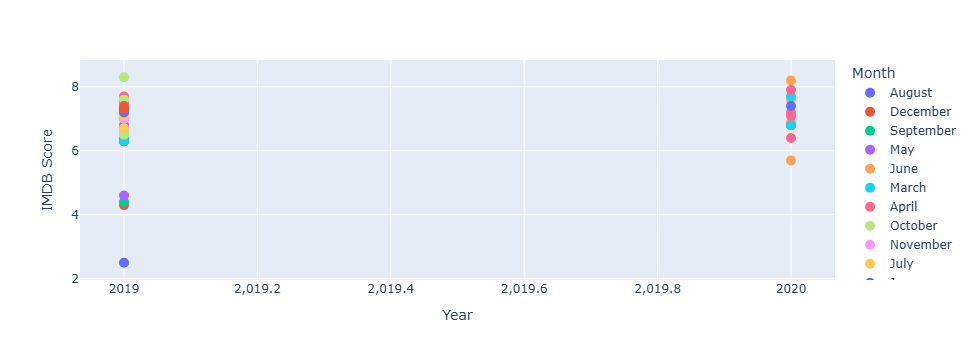

In [102]:
fig = px.scatter(df_doc, x='Year', y='IMDB Score',color="Month")
fig.update_traces(marker_size=10)
fig.show()

# 3-Which genre has the highest IMDB rating among movies shot in English?

In [103]:
top_imdb_english = df[df["Language"]=="English"]

In [104]:
top_imdb_english

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Month,Weekday
3,The Open House,Horror thriller,2018-01-19,94,3.2,English,2018,January,Friday
7,The Last Days of American Crime,Heist film/Thriller,2020-06-05,149,3.7,English,2020,June,Friday
8,Paradox,Musical/Western/Fantasy,2018-03-23,73,3.9,English,2018,March,Friday
10,Searching for Sheela,Documentary,2021-04-22,58,4.1,English,2021,April,Thursday
14,Mercy,Thriller,2016-11-22,90,4.2,English,2016,November,Tuesday
...,...,...,...,...,...,...,...,...,...
577,Dancing with the Birds,Documentary,2019-10-23,51,8.3,English,2019,October,Wednesday
578,Ben Platt: Live from Radio City Music Hall,Concert Film,2020-05-20,85,8.4,English,2020,May,Wednesday
579,Taylor Swift: Reputation Stadium Tour,Concert Film,2018-12-31,125,8.4,English,2018,December,Monday
581,Springsteen on Broadway,One-man show,2018-12-16,153,8.5,English,2018,December,Sunday


In [105]:
top_imdb_english = top_imdb_english.groupby("Genre")["IMDB Score"].mean().sort_values(ascending=False).head(5)
top_imdb_english

Genre
Animation/Christmas/Comedy/Adventure    8.200000
Musical / Short                         7.700000
Concert Film                            7.633333
Animation / Science Fiction             7.500000
Drama-Comedy                            7.200000
Name: IMDB Score, dtype: float64

# 4-What is the average 'runtime' of movies shot in 'Hindi'?

In [106]:
df_hindi = df[df["Language"] == "Hindi"]
avg_runtime = df_hindi["Runtime"].mean()
avg_runtime

np.float64(115.78787878787878)

In [107]:
df["Genre"].nunique()

115

# 5-How many categories does the Genre Column have and what are they? Visualize it.

In [108]:
genre = df["Genre"].value_counts()
genre

Genre
Documentary                             159
Drama                                    77
Comedy                                   49
Romantic comedy                          39
Thriller                                 33
                                       ... 
Action-adventure                          1
Animation / Science Fiction               1
Anthology/Dark comedy                     1
Musical / Short                           1
Animation/Christmas/Comedy/Adventure      1
Name: count, Length: 115, dtype: int64

In [109]:
df["Genre"].value_counts().sum()

np.int64(584)

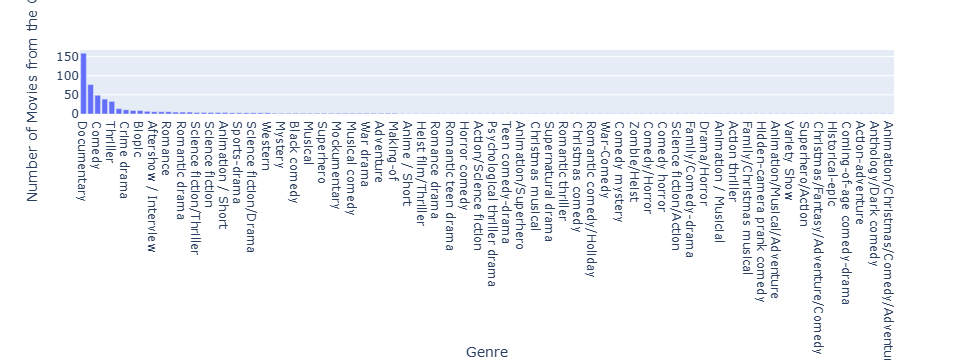

In [110]:
fig = px.bar(genre, x= genre.index, y=genre.values,labels={'y':'Number of Movies from the Genre', 'index':'Genres'})
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()
             

# 6-Find the 3 most used languages in the movies in the data set.

In [111]:
df_top_lang = df.Language.value_counts().nlargest(3)
df_top_lang

Language
English    401
Hindi       33
Spanish     31
Name: count, dtype: int64

# Another Way

In [112]:
top_languages = (df["Language"].value_counts().reset_index().head(3))
top_languages

,Language,count
0,English,401
1,Hindi,33
2,Spanish,31


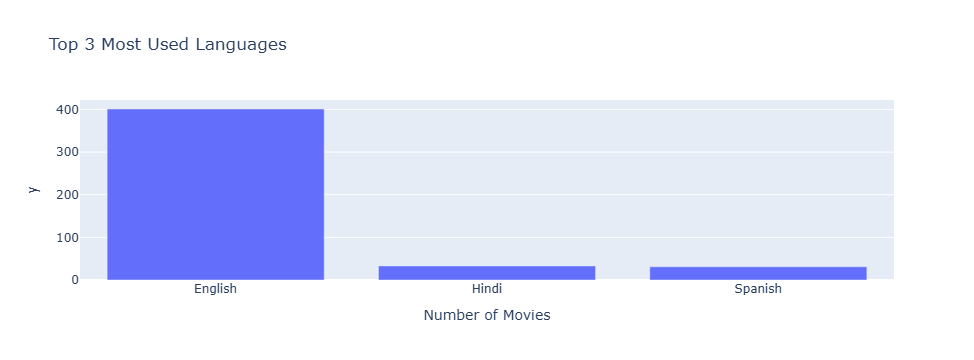

In [113]:
import plotly.express as px

fig = px.bar(
   df_top_lang.reset_index(),x=df_top_lang.index,y=df_top_lang.values,labels={"index": "Language", "Language": "Number of Movies"},
    title="Top 3 Most Used Languages"
)

fig.show()

# 7- Top 10 Movies With IMDB Ratings

In [114]:
top_10 = df.sort_values(by="IMDB Score", ascending=False).head(10)
top_10[["Title", "Genre", "Language", "IMDB Score"]]

,Title,Genre,Language,IMDB Score
583,David Attenborough: A Life on Our Planet,Documentary,English,9.0
582,Emicida: AmarElo - It's All For Yesterday,Documentary,Portuguese,8.6
581,Springsteen on Broadway,One-man show,English,8.5
579,Taylor Swift: Reputation Stadium Tour,Concert Film,English,8.4
578,Ben Platt: Live from Radio City Music Hall,Concert Film,English,8.4
580,Winter on Fire: Ukraine's Fight for Freedom,Documentary,English/Ukranian/Russian,8.4
576,Cuba and the Cameraman,Documentary,English,8.3
577,Dancing with the Birds,Documentary,English,8.3
575,The Three Deaths of Marisela Escobedo,Documentary,Spanish,8.2
574,Seaspiracy,Documentary,English,8.2


# Another Way

In [115]:
df.nlargest(10, "IMDB Score")[["Title","Genre","IMDB Score"]]

,Title,Genre,IMDB Score
583,David Attenborough: A Life on Our Planet,Documentary,9.0
582,Emicida: AmarElo - It's All For Yesterday,Documentary,8.6
581,Springsteen on Broadway,One-man show,8.5
578,Ben Platt: Live from Radio City Music Hall,Concert Film,8.4
579,Taylor Swift: Reputation Stadium Tour,Concert Film,8.4
580,Winter on Fire: Ukraine's Fight for Freedom,Documentary,8.4
576,Cuba and the Cameraman,Documentary,8.3
577,Dancing with the Birds,Documentary,8.3
571,13th,Documentary,8.2
572,Disclosure: Trans Lives on Screen,Documentary,8.2


# Another Way

In [116]:
df_temp=df.sort_values(by='IMDB Score', ascending=False).reset_index().iloc[:13,:]

In [117]:
df_temp

,index,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Month,Weekday
0,583,David Attenborough: A Life on Our Planet,Documentary,2020-10-04,83,9.0,English,2020,October,Sunday
1,582,Emicida: AmarElo - It's All For Yesterday,Documentary,2020-12-08,89,8.6,Portuguese,2020,December,Tuesday
2,581,Springsteen on Broadway,One-man show,2018-12-16,153,8.5,English,2018,December,Sunday
3,579,Taylor Swift: Reputation Stadium Tour,Concert Film,2018-12-31,125,8.4,English,2018,December,Monday
4,578,Ben Platt: Live from Radio City Music Hall,Concert Film,2020-05-20,85,8.4,English,2020,May,Wednesday
5,580,Winter on Fire: Ukraine's Fight for Freedom,Documentary,2015-10-09,91,8.4,English/Ukranian/Russian,2015,October,Friday
6,576,Cuba and the Cameraman,Documentary,2017-11-24,114,8.3,English,2017,November,Friday
7,577,Dancing with the Birds,Documentary,2019-10-23,51,8.3,English,2019,October,Wednesday
8,575,The Three Deaths of Marisela Escobedo,Documentary,2020-10-14,109,8.2,Spanish,2020,October,Wednesday
9,574,Seaspiracy,Documentary,2021-03-24,89,8.2,English,2021,March,Wednesday


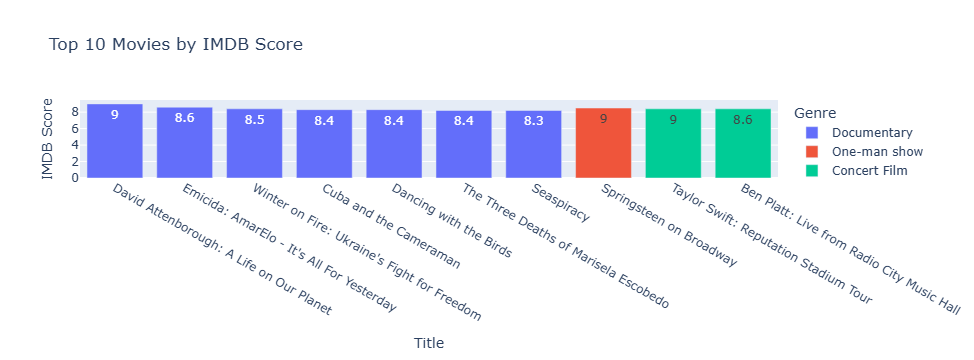

In [118]:
import plotly.express as px

fig = px.bar(
    top_10,
    x="Title",
    y="IMDB Score",
    color="Genre",
    title="Top 10 Movies by IMDB Score"
)

fig.update_traces(text=top_10["IMDB Score"], textposition="inside")

fig.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13376\2768390431.py:15: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



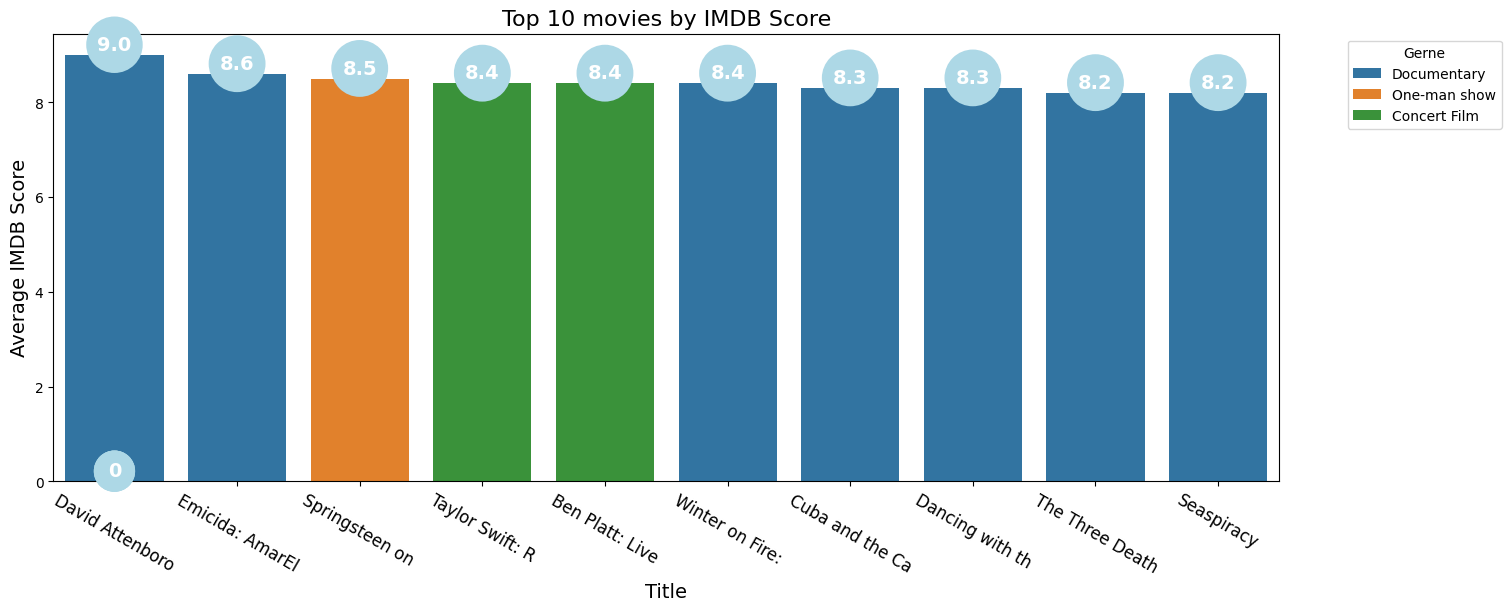

In [119]:
df_temp=df.sort_values(by='IMDB Score', ascending=False).reset_index().iloc[:10,:]

fig, ax = plt.subplots(1,1, figsize = (15, 6), constrained_layout = True)
ax = sns.barplot(x = 'Title', y = 'IMDB Score', data = df_temp, hue = 'Genre')

for i in ax.patches:    
    ax.text(x = i.get_x() + i.get_width()/2, y = i.get_height()+0.1,
            s = f"{i.get_height()}", 
            ha = 'center', size = 14, weight = 'bold', rotation = 0, color = 'white',
            bbox=dict(boxstyle="circle,pad=0.5", fc='lightblue', ec="lightblue", lw=2))


ax.set_xlabel('Title', fontsize=14)
ax.set_ylabel('Average IMDB Score', fontsize=14)
ax.set_xticklabels([i[:15] for i in df_temp['Title'].unique()], fontsize=12, rotation = -30)
plt.title('Top 10 movies by IMDB Score', fontsize=16)
plt.legend(title='Gerne', bbox_to_anchor=(1.05, 1), loc='upper left');

# 8-What is the correlation between IMDB score and 'Runtime'? Examine and visualize.

In [120]:
df[['IMDB Score','Runtime']].corr()

,IMDB Score,Runtime
IMDB Score,1.000000,-0.040896
Runtime,-0.040896,1.000000


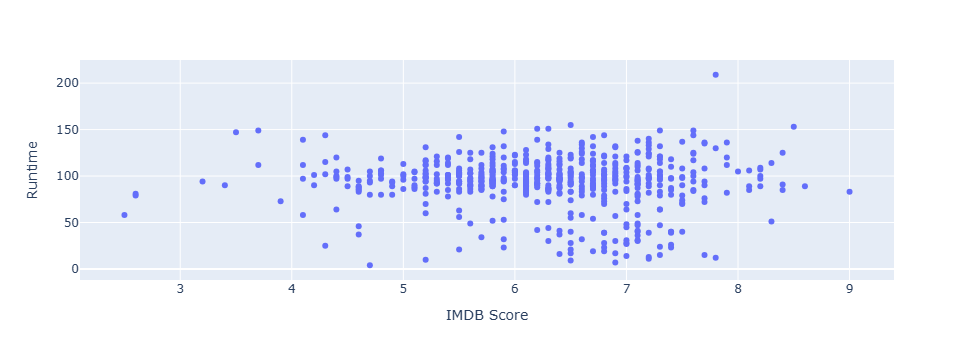

In [121]:
fig = px.scatter(df, x='IMDB Score', y='Runtime')
fig.show()

# 9-Top 10 Genre by IMDB Score

In [122]:
top_genre = df.groupby("Genre")["IMDB Score"].mean().sort_values(ascending=False).head(10)


In [123]:
top_genre

Genre
Animation/Christmas/Comedy/Adventure    8.200000
Musical / Short                         7.700000
Concert Film                            7.633333
Anthology/Dark comedy                   7.600000
Animation / Science Fiction             7.500000
Making-of                               7.450000
Action-adventure                        7.300000
Drama-Comedy                            7.200000
Historical drama                        7.200000
Coming-of-age comedy-drama              7.200000
Name: IMDB Score, dtype: float64

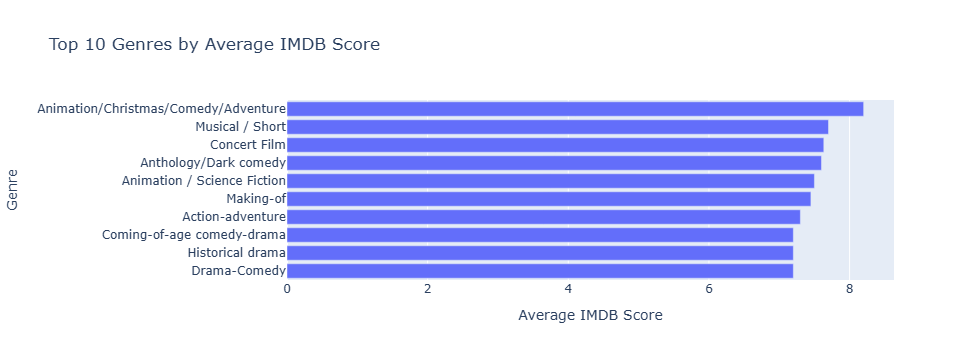

In [124]:
import plotly.express as px

fig = px.bar(
    top_genre.reset_index(),
    x="IMDB Score",
    y="Genre",
    orientation="h",
    title="Top 10 Genres by Average IMDB Score",
    labels={
        "IMDB Score": "Average IMDB Score",
        "Genre": "Genre"
    }
)

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

# 10-What are the top 10 movies with the highest 'runtime'? Visualize it.

In [125]:
df_temp=df.groupby(['Title']).mean(['Runtime rating']).sort_values(by='Runtime', ascending=False).reset_index().iloc[:10,:2]


In [126]:
df_temp

,Title,Runtime
0,The Irishman,209.0
1,Da 5 Bloods,155.0
2,Springsteen on Broadway,153.0
3,The Forest of Love,151.0
4,Citation,151.0
5,The Last Days of American Crime,149.0
6,Ludo,149.0
7,Raat Akeli Hai,149.0
8,Army of the Dead,148.0
9,Drive,147.0


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13376\206356799.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




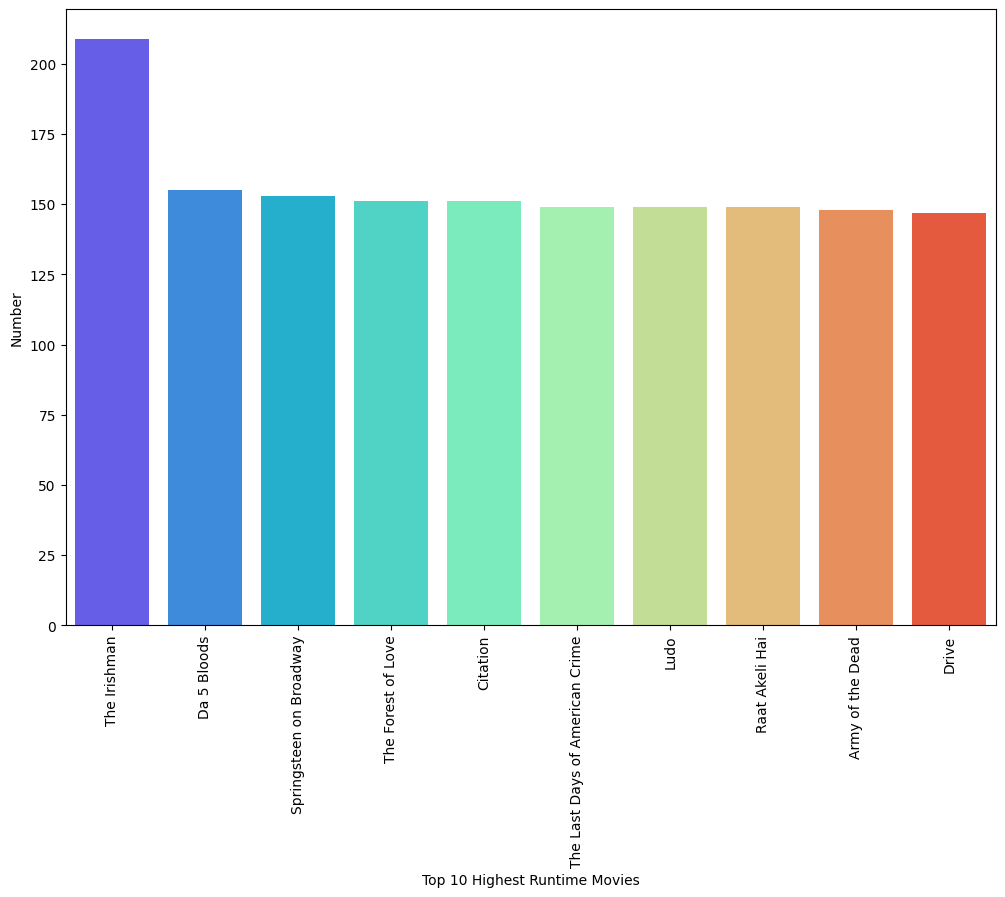

In [127]:
plt.figure(figsize=(12,8))
sns.barplot(x=df_temp["Title"],y=df_temp["Runtime"],data=df,palette='rainbow')
plt.xlabel('Top 10 Highest Runtime Movies')
plt.xticks(rotation=90)
plt.ylabel('Number')
plt.show()

# Another Way

In [128]:
top10_title = df.groupby("Title")["Runtime"].mean().sort_values(ascending=False).reset_index().head(10)

In [129]:
top10_title

,Title,Runtime
0,The Irishman,209.0
1,Da 5 Bloods,155.0
2,Springsteen on Broadway,153.0
3,The Forest of Love,151.0
4,Citation,151.0
5,The Last Days of American Crime,149.0
6,Ludo,149.0
7,Raat Akeli Hai,149.0
8,Army of the Dead,148.0
9,Drive,147.0


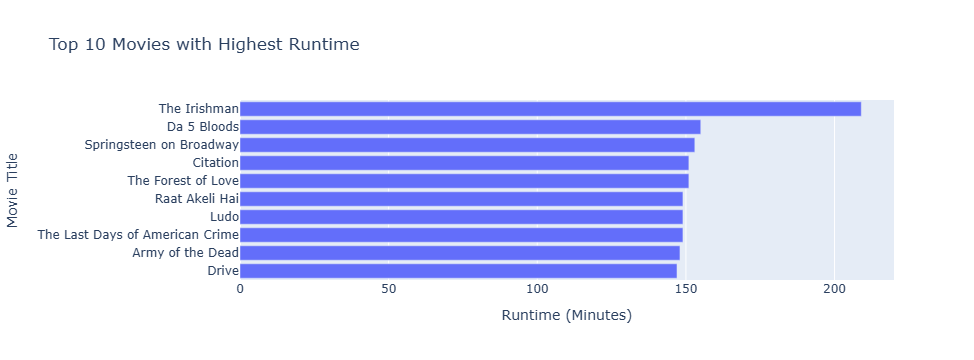

In [130]:
fig = px.bar(
    top10_title,
    x="Runtime",
    y="Title",
    orientation="h",
    title="Top 10 Movies with Highest Runtime",
    labels={
        "Runtime": "Runtime (Minutes)",
        "Title": "Movie Title"
    }
)

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

# 11-In which year was the most movies released? Visualize it.

In [131]:
movies_per_year = df.groupby("Year")["Title"].count().reset_index(name="Movie_Count").sort_values(by="Movie_Count", ascending=False)

In [132]:
movies_per_year

,Year,Movie_Count
6,2020,183
5,2019,124
4,2018,99
7,2021,71
3,2017,64
2,2016,28
1,2015,9
0,2014,1


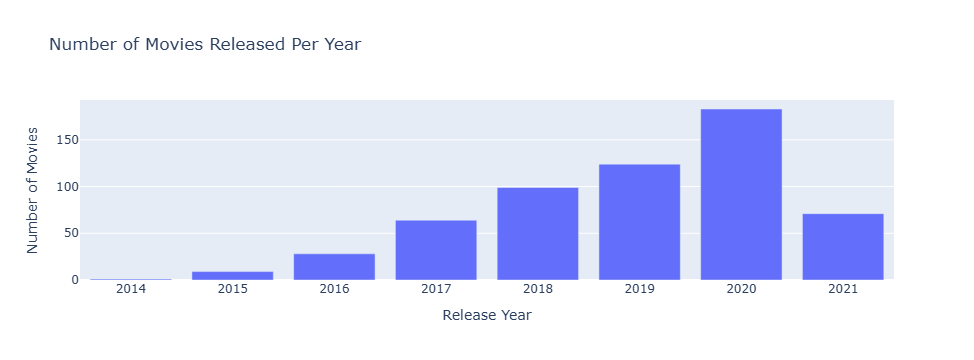

In [133]:
import plotly.express as px

fig = px.bar(
    movies_per_year,
    x="Year",
    y="Movie_Count",
    title="Number of Movies Released Per Year",
    labels={
        "Year": "Release Year",
        "Movie_Count": "Number of Movies"
    }
)

fig.show()

# 12-Is there any outlier data in the data set? Please explain.
   Let's look the Runtime for detecting outlier. We can easily see one outlier with no doubt. The outlier of Runtime column' is "The Irishman"

In [134]:
Q1 = df['Runtime'].quantile(0.25)
Q3 = df['Runtime'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [135]:
outliers = df[(df['Runtime'] < lower_bound) | 
              (df['Runtime'] > upper_bound)]

In [136]:
outliers[['Title', 'Runtime']]

,Title,Runtime
5,Drive,147
7,The Last Days of American Crime,149
15,After the Raid,25
16,Ghost Stories,144
30,After Maria,37
...,...,...
552,Anima,15
560,If Anything Happens I Love You,12
561,The Irishman,209
577,Dancing with the Birds,51


In [137]:
df[df['Runtime']==209]

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Month,Weekday
561,The Irishman,Crime drama,2019-11-27,209,7.8,English,2019,November,Wednesday


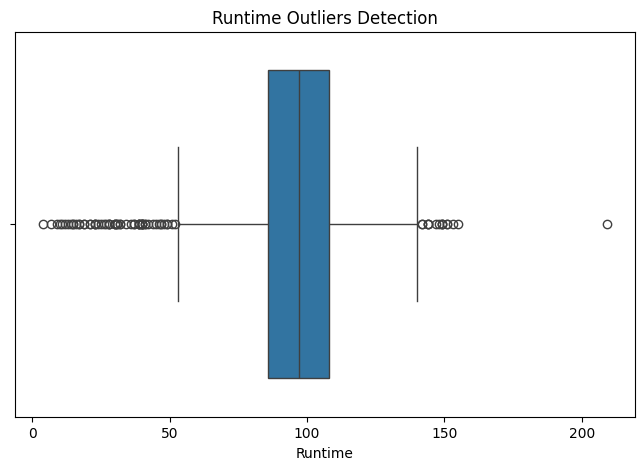

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Runtime'])

plt.title("Runtime Outliers Detection")
plt.show()

# 13-What is the "Genre" where each language is used the most?

In [139]:
lang_genre_count =df.groupby(["Language", "Genre"])["Title"].count().reset_index(name="Movie_Count")
lang_genre_count

,Language,Genre,Movie_Count
0,Bengali,Documentary,1
1,Dutch,Crime drama,1
2,Dutch,Fantasy,1
3,Dutch,Romantic comedy,1
4,English,Action,4
...,...,...,...
199,Thai,Horror,1
200,Thia/English,Documentary,1
201,Turkish,Comedy,2
202,Turkish,Drama,2


In [140]:
top_genre_per_language =lang_genre_count.sort_values(["Language", "Movie_Count"], ascending=[True, False]).groupby("Language").head(1).reset_index(drop=True)
top_genre_per_language

,Language,Genre,Movie_Count
0,Bengali,Documentary,1
1,Dutch,Crime drama,1
2,English,Documentary,120
3,English/Akan,War drama,1
4,English/Arabic,Documentary,1
5,English/Hindi,Documentary,2
6,English/Japanese,Crime drama,1
7,English/Korean,Action-adventure,1
8,English/Mandarin,Documentary,2
9,English/Russian,Documentary,1


# Another Way

In [141]:
genre_lang =[]
for i in df.Language.unique():
    df_lang =df[df["Language"]==i]
    df_lang_genre =df_lang.Genre.value_counts().nlargest(1)
    #print(f'*************************************************')
    #print(f'Language: {i}\n', df_lang_genre)
    genre_lang.append((i,df_lang_genre))

In [142]:
df_lang = pd.DataFrame(genre_lang, columns = ['Language', 'Genre'])

In [143]:
df_lang.sort_values(by=['Language'],ignore_index=True)

,Language,Genre
0,Bengali,"Genre Documentary 1 Name: count, dtype: int64"
1,Dutch,"Genre Romantic comedy 1 Name: count, dtype:..."
2,English,"Genre Documentary 120 Name: count, dtype: i..."
3,English/Akan,"Genre War drama 1 Name: count, dtype: int64"
4,English/Arabic,"Genre Documentary 1 Name: count, dtype: int64"
5,English/Hindi,"Genre Documentary 2 Name: count, dtype: int64"
6,English/Japanese,"Genre Documentary 1 Name: count, dtype: int64"
7,English/Korean,"Genre Action-adventure 1 Name: count, dtype..."
8,English/Mandarin,"Genre Documentary 2 Name: count, dtype: int64"
9,English/Russian,"Genre Documentary 1 Name: count, dtype: int64"


# 14-Which year has the greatest total runtime?

In [148]:
year_runtime = df.groupby("Year")["Runtime"].sum().reset_index(name="Total_Runtime").sort_values(by='Total_Runtime',ascending= False).head(5)

In [149]:
year_runtime

,Year,Total_Runtime
6,2020,17384
5,2019,10835
4,2018,9405
7,2021,7214
3,2017,5924


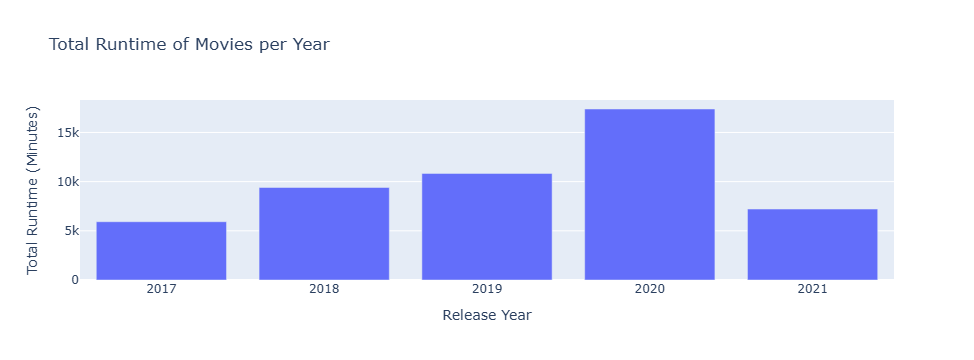

In [150]:
import plotly.express as px

fig = px.bar(
    year_runtime,
    x="Year",
    y="Total_Runtime",
    title="Total Runtime of Movies per Year",
    labels={
        "Year": "Release Year",
        "Total_Runtime": "Total Runtime (Minutes)"
    }
)
fig.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13376\2201858587.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




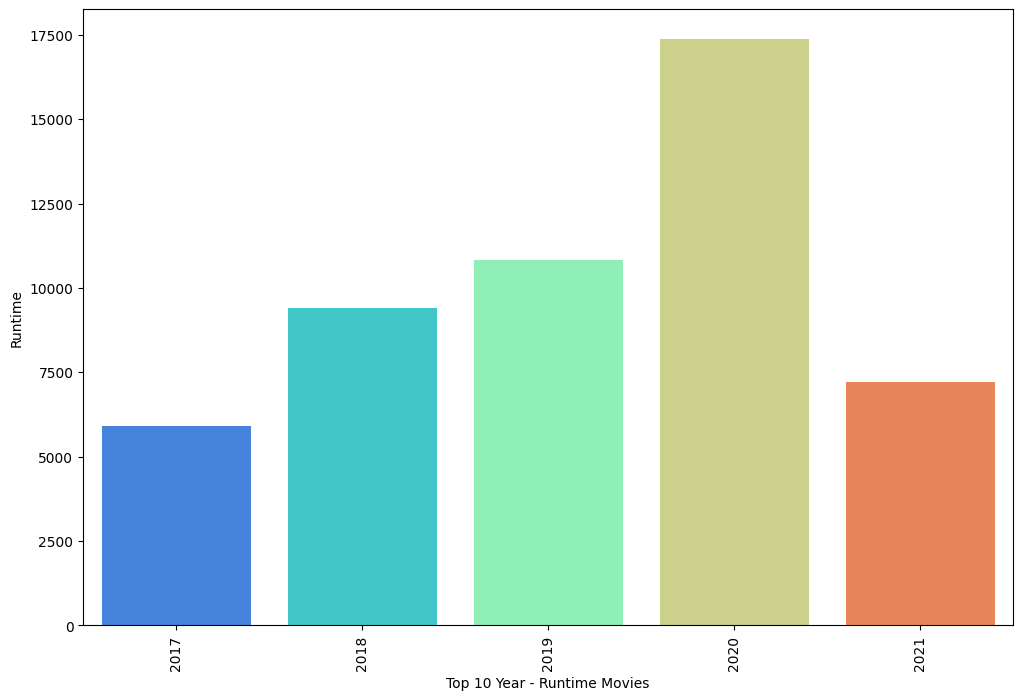

In [151]:
# plotting a bar graph for better visualisation
plt.figure(figsize=(12,8))
sns.barplot(x=year_runtime["Year"],y=year_runtime["Total_Runtime"],data=df,palette='rainbow')
plt.xlabel('Top 10 Year - Runtime Movies')
plt.xticks(rotation=90)
plt.ylabel('Runtime')
plt.show()
     

# 15-Which language movies have the lowest average IMDB rating? Visualize it.

In [156]:
lang_avg_IMDB = df.groupby("Language")["IMDB Score"].mean().reset_index(name="Avg_IMDB").sort_values(by="Avg_IMDB",ascending=True).head(10)

In [157]:
lang_avg_IMDB

,Language,Avg_IMDB
24,Malay,4.200000
6,English/Japanese,4.400000
26,Norwegian,5.100000
14,Filipino,5.100000
27,Polish,5.166667
35,Thai,5.450000
33,Swedish,5.500000
20,Italian,5.542857
30,Spanish/Basque,5.600000
17,German,5.640000


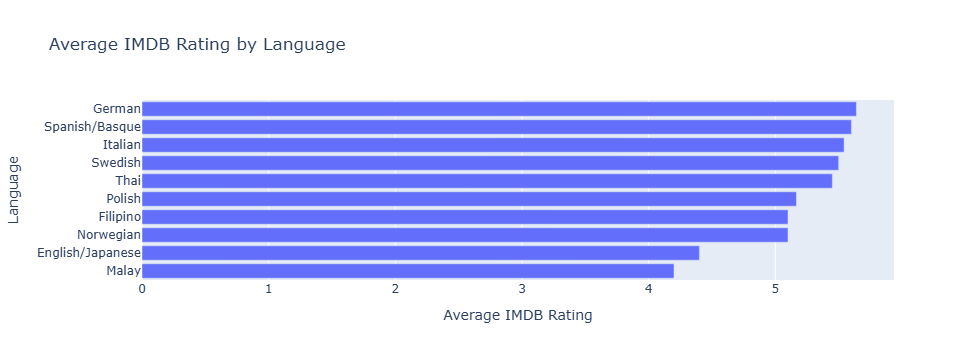

In [158]:
import plotly.express as px

fig = px.bar(
    lang_avg_IMDB,
    x="Avg_IMDB",
    y="Language",
    orientation="h",
    title="Average IMDB Rating by Language",
    labels={
        "Avg_IMDB": "Average IMDB Rating",
        "Language": "Language"
    }
)

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()